# Volumetric Ergodic Control Tutorial: MPC Ground Search

2D MPC ground-search task with second-order differential-drive dynamics. The target is a Gaussian mixture search distribution, and the volumetric state is modeled as a forward-facing solid-state LiDAR.

In [11]:
# Imports and device setup

from functools import partial
import imageio.v2 as imageio
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Video, display
from jax import grad, jit, vmap
from jax.scipy.stats import multivariate_normal as mvn
from tqdm.auto import tqdm

try:
    from lqrax import iLQR
except ImportError:
    %pip install lqrax
    from lqrax import iLQR

jnp.set_printoptions(precision=4, suppress=True)

try:
    device = jax.devices("gpu")[0]
except RuntimeError:
    device = jax.devices("cpu")[0]
print("Using device:", device)

Using device: cuda:0


### Configure the Search Task

In [12]:
# Initial robot state
_x0 = jnp.array([0.2, 0.2])
_theta0 = 0.0

# Set parameters
dt = 0.05
tsteps = 50
T = dt * tsteps

In [13]:
# Define the agent dynamics
class DiffDriveAgent(iLQR):
    def __init__(self, dt, x_dim, u_dim, Q, R):
        super().__init__(dt, x_dim, u_dim, Q, R)

    def dyn(self, xt, ut):
        """
        Second-order differential-drive dynamics.

        State: xt = [x, y, theta, v, omega]
        Control: ut = [a_v, a_omega]
        Returns: xdot = [v*cos(theta), v*sin(theta), omega, a_v, a_omega]
        """
        x, y, theta, v, omega = xt
        a_v, a_omega = ut
        return jnp.array([
            v * jnp.cos(theta),
            v * jnp.sin(theta),
            omega,
            a_v,
            a_omega,
        ])

Q = jnp.diag(jnp.array([0.1, 0.1, 0.001, 0.001, 0.001]))
R = jnp.diag(jnp.array([0.01, 0.01]))

car_ilqr = DiffDriveAgent(dt=dt, x_dim=5, u_dim=2, Q=Q, R=R)

linearize_dyn = jit(car_ilqr.linearize_dyn, device=device)
solve_ilqr = jit(car_ilqr.solve, device=device)

L_list = jnp.array([1.0, 1.0]) # boundaries for each dimension

### Target Fourier Coefficients

The ergodic metric compares Fourier coefficients of the target distribution and the trajectory distribution. The target distribution is the Gaussian mixture, and the discrete targets are used solely as a task-level detection metric.

In [14]:
grid_points = 100

grids_x, grids_y = jnp.meshgrid(
    jnp.linspace(0, L_list[0], grid_points),
    jnp.linspace(0, L_list[1], grid_points),
)
grids = jnp.array([grids_x.ravel(), grids_y.ravel()]).T
dx = grids_x[0, 1] - grids_x[0, 0]
dy = grids_y[1, 0] - grids_y[0, 0]

# Define the target distribution as a Gaussian mixture
def gaussian(x): 
    mean1 = jnp.array([0.35, 0.38]) 
    mean2 = jnp.array([0.68, 0.25]) 
    mean3 = jnp.array([0.56, 0.64]) 
    cov1 = jnp.array([ [0.01, 0.004], [0.004, 0.01] ]) 
    cov2 = jnp.array([ [0.005, -0.003], [-0.003, 0.005] ]) 
    cov3 = jnp.array([ [0.008, 0.0], [0.0, 0.004] ]) 
    w1, w2, w3 = 0.5, 0.2, 0.3 
    return w1 * mvn.pdf(x, mean1, cov1) + w2 * mvn.pdf(x, mean2, cov2) + w3 * mvn.pdf(x, mean3, cov3)

# Use the Gaussian means as targets for this tutorial
targets = jnp.array([
    [0.35, 0.38],
    [0.68, 0.25],
    [0.56, 0.64],
])
num_targets = int(targets.shape[0])

In [15]:
# Configure the index vectors
numk = 20 # number of basis functions for each dimension
ks_1, ks_2 = jnp.meshgrid(jnp.arange(numk), jnp.arange(numk))
ks = jnp.array([ks_1.ravel(), ks_2.ravel()]).T

# Sobolev weights and normalization constants
lamks = (1.0 + jnp.linalg.norm(ks, axis=1)) ** (-3/2.0)
fk_grids = jnp.prod(jnp.cos(jnp.pi* (grids[:, None, :] * ks[None, :, :])/ jnp.array(L_list)[None, None, :]), axis=-1)
hks = jnp.sqrt(jnp.sum(jnp.square(fk_grids), axis=0) * dx * dy)

# Set target distribution
tgt_distr = vmap(gaussian)(grids)
tgt_distr /= jnp.sum(tgt_distr) * dx * dy
phiks = jnp.sum(fk_grids / hks * tgt_distr[:, None], axis=0) * dx * dy  # target coefficients

### Volumetric Ergodic Metric

VEC replaces point-based trajectory statistics with averages of the Fourier basis over the sensor’s volumetric state. Here, the sensor is modeled as a forward-facing solid-state LiDAR.

In [16]:
# Forward-facing solid-state LiDAR parameters
r_max = 0.3
cone_deg = 30.0
cone_deg_rad = jnp.deg2rad(cone_deg)
num_rays = 15
num_samples = 15
detect_radius = 0.01

In [17]:
@jit
def lidar_points(xt):
    """Solid-state LiDAR samples"""
    x, y, theta = xt[0], xt[1], xt[2]
    c, s = jnp.cos(theta), jnp.sin(theta)
    R = jnp.array([[c, -s],
                   [s,  c]])
    pos = jnp.array([x, y])

    # Sensor origin is at the front of the differential-drive body.
    offset_x_body = 0.1
    pos = pos + R @ jnp.array([offset_x_body, 0.0])

    deltas = jnp.linspace(-cone_deg_rad, cone_deg_rad, num_rays)
    r_lin = jnp.linspace(0.0, r_max, num_samples)
    d_grid, r_grid = jnp.meshgrid(deltas, r_lin, indexing="xy")

    dir_body = jnp.stack([jnp.cos(d_grid), jnp.sin(d_grid)], axis=-1)
    dir_world = dir_body @ R.T

    pts_raw = pos[None, None, :] + dir_world * r_grid[..., None]
    pts_raw = pts_raw.reshape(-1, 2)

    inside = (pts_raw[:, 0] >= 0.0) & (pts_raw[:, 0] <= L_list[0]) & \
             (pts_raw[:, 1] >= 0.0) & (pts_raw[:, 1] <= L_list[1])
    w = inside.astype(jnp.float32)

    pts_clip = jnp.clip(pts_raw, jnp.array([0.0, 0.0]), L_list)
    return pts_raw, pts_clip, w

def detect_targets(xt, found_mask_np):
    """Update the mask of targets detected by the solid-state LiDAR"""
    _, pts_on_ground, w = lidar_points(xt)
    
    # Distances from each lidar points to each target 
    diff = pts_on_ground[:, None, :] - targets[None, :, :]
    d2 = jnp.sum(diff * diff, axis=-1)
    d2 = d2 + (1.0 - w)[:, None] * 1e9
    min_d2 = jnp.min(d2, axis=0)

    newly_found = np.array(min_d2 <= (detect_radius ** 2))
    return found_mask_np | newly_found

@jit
def fks_x(x):
    """Standard point-based Fourier basis"""
    return jnp.prod(jnp.cos(jnp.pi * ks * x[:2] / L_list), axis=-1) / hks

@jit
def fks_x_footprint(x):
    """Volumetric Fourier basis"""
    _, pts_clip, w = lidar_points(x)
    fk_pts = vmap(fks_x)(pts_clip)
    w_sum = jnp.sum(w)
    avg = jnp.sum(fk_pts * w[:, None], axis=0) / (w_sum + 1e-8)
    return jnp.where(w_sum > 0.0, avg, jnp.zeros_like(avg))

def barr(x_traj):
    """Barrier function to keep the robot inside the search space."""
    def barr_xt(xt):
        upper_bnd = jnp.array([0.95, 0.95])
        lower_bnd = jnp.array([0.05, 0.05])
        penalty_high = jnp.maximum(xt[:2] - upper_bnd, 0.0)
        penalty_low = jnp.maximum(lower_bnd - xt[:2], 0.0)
        val = jnp.sum(jnp.square(penalty_high)) + jnp.sum(jnp.square(penalty_low))
        return val * 10.0
    barr_traj = jax.vmap(barr_xt)(x_traj)
    return jnp.sum(barr_traj) * dt


def fourier_metric(x_traj, fk_sum_prev, T1, T2):
    """
    Receding-horizon volumetric ergodic metric.
    
    The key difference for MPC is to take into account previous trajectory when
    evaluating the ergodic metric.
    
    Here x_traj is the future trajectory that is being evaluated,
    fk_sum_prev is the summation (not average) of Fourier coefficients from all the previous states
    T1 is the planning time horizon (which is usually fixed)
    T2 is the number of time steps of the previous trajectory (which increases over time)
    """
    # fk_traj = vmap(fks_x)(x_traj)  # point-based baseline
    fk_traj = vmap(fks_x_footprint)(x_traj)
    
    cks = (jnp.sum(fk_traj, axis=0) + fk_sum_prev) / (T1 + T2)
    loss = jnp.sum(lamks * jnp.square(cks - phiks))
    return loss + barr(x_traj)

# Autodiff the derivative of the Fourier ergodic metric
d_fourier_traj = grad(fourier_metric)

fourier_metric = jit(fourier_metric, device=device)
d_fourier_traj = jit(d_fourier_traj, device=device)


### iLQR Optimization Step

Each MPC step optimizes a short control sequence. The first optimized control is executed, then the problem is solved again from the new state.


In [18]:
@partial(jit, device=device)
def line_search(x0, u_traj, v_traj, fk_sum_prev, T1, T2):
    step_sizes = jnp.power(2.0, jnp.linspace(-5.0, 3.0, 20))
    u_traj_batch = u_traj[None, :, :] + step_sizes[:, None, None] * v_traj[None, :, :]
    x_traj_batch = vmap(car_ilqr.traj_sim, in_axes=(None, 0))(x0, u_traj_batch)
    x_traj_batch = jax.device_put(x_traj_batch, device=device)
    costs = vmap(fourier_metric, in_axes=(0, None, None, None))(x_traj_batch, fk_sum_prev, T1, T2)
    return step_sizes[jnp.argmin(costs)]

def ilqr_iter(x0, u_traj, fk_sum_prev, T1, T2):
    x_traj, A_traj, B_traj = linearize_dyn(x0, u_traj)
    fourier_dx_traj = d_fourier_traj(x_traj, fk_sum_prev, T1, T2)
    b_traj = jnp.zeros_like(u_traj)
    v_traj, z_traj = solve_ilqr(A_traj, B_traj, fourier_dx_traj, b_traj)
    step_size = line_search(x0, u_traj, v_traj, fk_sum_prev, T1, T2)
    u_traj += step_size * v_traj
    return u_traj

@partial(jit, device=device)
def ilqr_opt(x0, init_u_traj, fk_sum_prev, T1, T2):
    num_iters = 30
    u_traj = init_u_traj
    for i in range(num_iters):
        u_traj = ilqr_iter(x0, u_traj, fk_sum_prev, T1, T2)
    x_traj = car_ilqr.traj_sim(x0, u_traj)
    return x_traj, u_traj

### Run MPC


In [19]:
# Initial conditions
x0 = jnp.array([_x0[0], _x0[1], _theta0, 0.0, 0.0])
u0 = jnp.array([0.0, 0.0])
u_traj = jnp.tile(u0, (tsteps, 1))

found_mask = np.zeros((num_targets,), dtype=bool)
found_step = np.full((num_targets,), -1, dtype=int)

In [20]:
erg_log, detected_log, x_traj_plan, x_traj_hist = [], [], [], []

# Running sum of volumetric Fourier coefficients
fk_sum_prev = jnp.zeros(ks.shape[0])
x_traj, u_traj = ilqr_opt(x0, u_traj, fk_sum_prev, tsteps, 0)

erg0 = float(fourier_metric(x_traj, fk_sum_prev, tsteps, 0))
erg_log.append(erg0)

x_traj_plan.append(jax.device_get(x_traj))
x_traj_hist.append(jax.device_get(x0))

found_mask = detect_targets(x0, found_mask)
detected_log.append(float(found_mask.mean()))

In [21]:
# Run the closed-loop MPC control loop
max_mpc_timestep = 500
num_timestep = 0

with tqdm(range(max_mpc_timestep), desc="MPC Loop") as pbar:
    for t in pbar:
        # Optimize the planned trajectory based on the current state and previous trajectory
        x_traj, u_traj = ilqr_opt(x0, u_traj, fk_sum_prev, tsteps, t)
        
        # Log the volumetric ergodic metric
        erg = fourier_metric(x_traj, fk_sum_prev, tsteps, t)
        erg_log.append(float(erg))
        
        # Update the summation of coefficients of previous states to include the current state
        fk_sum_prev += fks_x_footprint(x0)
        
        # Execute one MPC step
        x0 = x_traj[0]
        
        # Push all the controls in the sequence up for one time step (because the latest control has been excuted)
        u_traj = jnp.roll(u_traj, shift=-1, axis=0)
        # you can also simply reset the control to be zeros again, but it will look less smooth
        # u_traj = jnp.zeros((tsteps, 2))
        x_traj_plan.append(jax.device_get(x_traj))
        x_traj_hist.append(jax.device_get(x0))
        
        # Update the found mask and record the first-found step for each target
        prev_mask = found_mask.copy()
        found_mask = detect_targets(x0, found_mask)
        
        new_idx = np.where((~prev_mask) & found_mask)[0]
        for k in new_idx:
            found_step[k] = t # found at this MPC step

        num_timestep += 1
        detected_fraction = float(found_mask.mean())
        detected_log.append(detected_fraction)

        if bool(found_mask.all()):
            print(f"All targets found at step {t}.")
            break

        pbar.set_postfix({"ergodicity": f"{erg:.6f}", "detected": f"{detected_fraction:.2f}"})

x_traj_plan = np.stack(x_traj_plan, axis=0)
x_traj_hist = np.stack(x_traj_hist, axis=0)

print("Detected targets:", int(found_mask.sum()), "/", num_targets)
print("Found steps:", found_step)

MPC Loop:   0%|          | 0/500 [00:00<?, ?it/s]

All targets found at step 59.
Detected targets: 3 / 3
Found steps: [59  6 19]


## Visualize Results


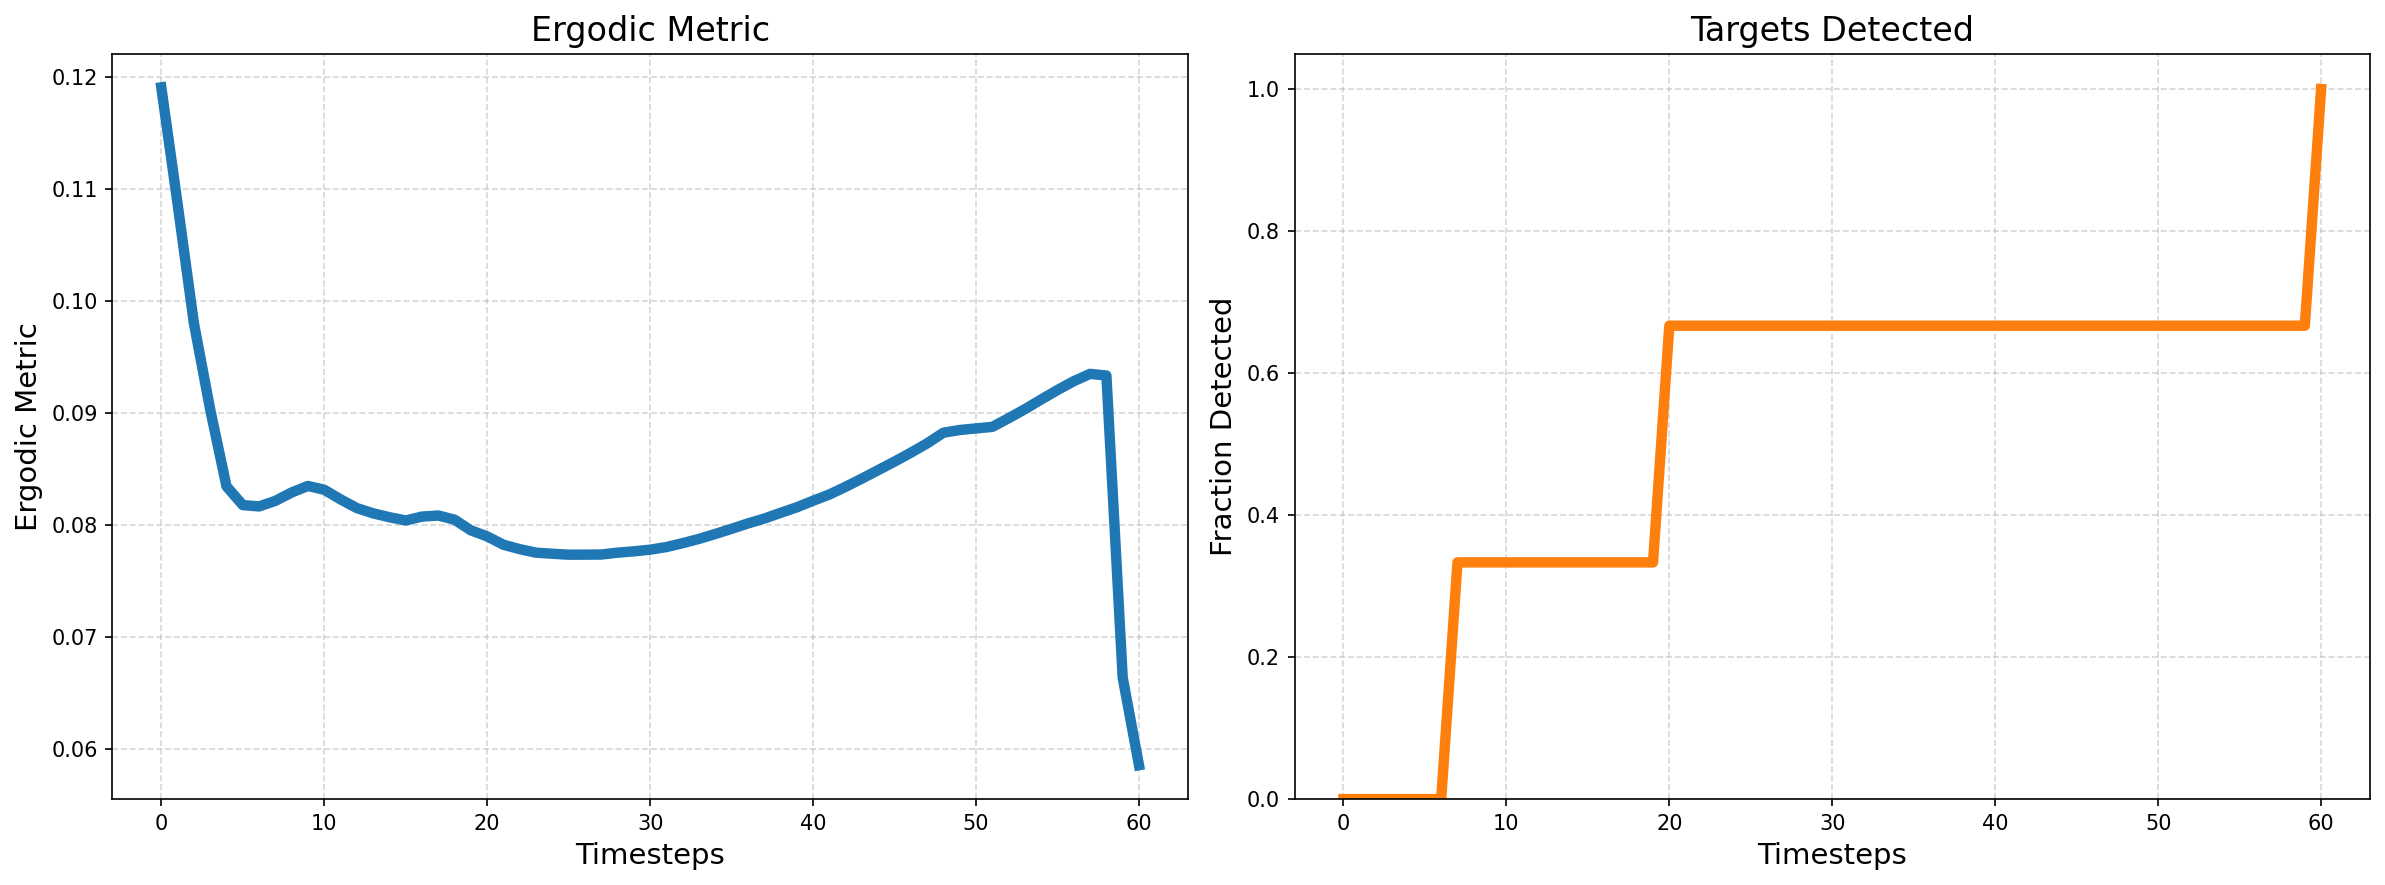

In [22]:
# Plot the ergodic metric and detected-target fraction
fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=150)

axes[0].plot(erg_log, color="C0", linewidth=5)
axes[0].set_title("Ergodic Metric", fontsize=16)
axes[0].set_xlabel("Timesteps", fontsize=14)
axes[0].set_ylabel("Ergodic Metric", fontsize=14)
axes[0].grid(True, linestyle="--", alpha=0.5)

axes[1].plot(detected_log, color="C1", linewidth=5)
axes[1].set_title("Targets Detected", fontsize=16)
axes[1].set_xlabel("Timesteps", fontsize=14)
axes[1].set_ylabel("Fraction Detected", fontsize=14)
axes[1].set_ylim(0, 1.05)
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


In [23]:
# Visualization helpers
from matplotlib.patches import Rectangle
from matplotlib.transforms import Affine2D

tgt_distr_grid = np.array(tgt_distr).reshape(np.array(grids_x).shape)
clevels = np.linspace(0.0, float(tgt_distr_grid.max()), 12)

def plot_diff_drive(ax, pose, offset_x_body=0.1):
    x, y, theta = float(pose[0]), float(pose[1]), float(pose[2])

    body_length = 2.0 * float(offset_x_body)
    body_width = 0.5 * body_length
    wheel_length = 0.4 * body_length
    wheel_width = 0.18 * body_length

    trans = Affine2D().rotate(theta).translate(x, y) + ax.transData

    body = Rectangle(
        (-body_length / 2, -body_width / 2),
        body_length,
        body_width,
        facecolor="#000000",
        edgecolor="#000000",
        lw=1,
        zorder=10,
        alpha=1.0,
    )
    body.set_transform(trans)
    ax.add_patch(body)

    cx = 0.25 * body_length
    cy = body_width / 2 + wheel_width / 2

    def add_wheel(cx_local, cy_local):
        wh = Rectangle(
            (cx_local - wheel_length / 2, cy_local - wheel_width / 2),
            wheel_length,
            wheel_width,
            facecolor="#FFFFFFFF",
            edgecolor="#000000",
            lw=1,
            zorder=11,
        )
        wh.set_transform(trans)
        ax.add_patch(wh)

    add_wheel(-cx, -cy)
    add_wheel(cx, -cy)
    add_wheel(-cx, cy)
    add_wheel(cx, cy)

def cone_points_np(xt):
    pts_raw, pts_clip, w = lidar_points(jnp.asarray(xt))
    return np.array(pts_raw), np.array(pts_clip), np.array(w)

def target_visible_at(i):
    visible = []
    for k, (tx, ty) in enumerate(np.array(targets)):
        if found_step[k] >= 0 and i >= found_step[k]:
            visible.append((tx, ty, True))
        else:
            visible.append((tx, ty, False))
    return visible

def plot_frame(ax, state, i, trail_pts=None, title=None):
    ax.clear()
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.0, 1.0)
    ax.set_aspect("equal")
    ax.axis("off")

    ax.contourf(np.array(grids_x), np.array(grids_y), tgt_distr_grid, levels=clevels[1:], cmap="Reds")

    if trail_pts is not None and len(trail_pts) > 0:
        ax.scatter(trail_pts[:, 0], trail_pts[:, 1], s=3, alpha=0.35, linewidths=0, color="#1D1D1DFF")

    pts_raw, _, _ = cone_points_np(state)
    ax.scatter(pts_raw[:, 0], pts_raw[:, 1], s=8, alpha=0.9, linewidths=0, color="#000000")

    for tx, ty, detected in target_visible_at(i):
        if detected:
            ax.plot(tx, ty, marker="X", markerfacecolor="C2", markeredgecolor="k", linestyle="", markersize=18, alpha=1.0)

    plot_diff_drive(ax, state, offset_x_body=0.1)

    if title:
        ax.set_title(title)

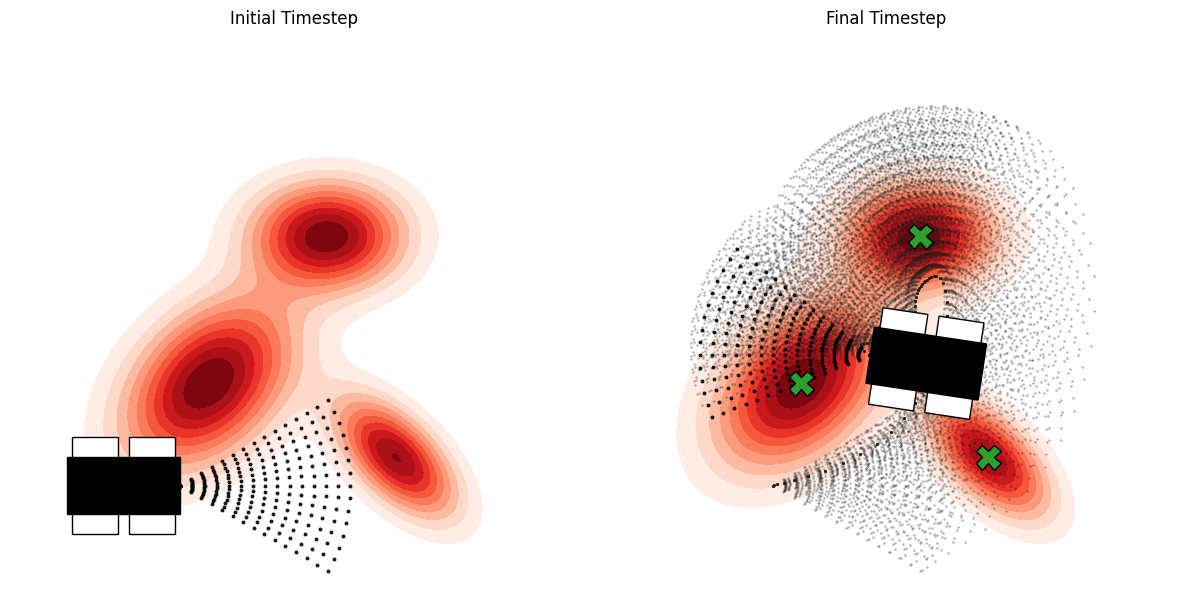

In [24]:
# Plot the initial and final timesteps
x_traj_hist_np = np.array(x_traj_hist)

pts_list_accum = []
for i in range(x_traj_hist_np.shape[0]):
    pts_raw_i, _, _ = cone_points_np(x_traj_hist_np[i])
    pts_list_accum.append(pts_raw_i)
trail_pts = np.vstack(pts_list_accum)

fig, axes = plt.subplots(1, 2, figsize=(12, 6), dpi=100, tight_layout=True)
plot_frame(axes[0], x_traj_hist_np[0], 0, trail_pts=None, title="Initial Timestep")
plot_frame(axes[1], x_traj_hist_np[-1], x_traj_hist_np.shape[0] - 1, trail_pts=trail_pts, title="Final Timestep")
plt.show()
plt.close()


### Render Video


In [25]:
video_frames = []
pts_list_accum = []

for i in tqdm(range(x_traj_hist_np.shape[0]), desc="Rendering video"):
    pts_raw_i, _, _ = cone_points_np(x_traj_hist_np[i])
    pts_list_accum.append(pts_raw_i)
    trail_pts = np.vstack(pts_list_accum)

    fig, ax = plt.subplots(1, 1, figsize=(6.4, 6.4), dpi=150)
    plot_frame(ax, x_traj_hist_np[i], i, trail_pts=trail_pts, title=f"Timestep: {i}")
    fig.tight_layout(pad=1.0)

    fig.canvas.draw()
    frame = np.asarray(fig.canvas.buffer_rgba(), dtype=np.uint8)[..., :3].copy()
    video_frames.append(frame)
    plt.close(fig)

print(f"Rendered {len(video_frames)} video frames.")


Rendering video:   0%|          | 0/61 [00:00<?, ?it/s]

Rendered 61 video frames.


In [26]:
video_path = "groundserach_mpc.mp4"
imageio.mimsave(video_path, video_frames, fps=30, codec="libx264", quality=10, macro_block_size=16)
print("Video saved:", video_path)

display(Video(video_path, embed=True, width=512, height=512))

/home/jueun2/miniconda3/envs/jax/lib/python3.12/subprocess.py:1885: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = _fork_exec(


Video saved: groundserach_mpc.mp4
